# Preprocessing delle Immagini (introduzione)
Notebook per: immagini come matrici, canali, operazioni pixel-wise, globali, locali (convoluzione) e padding.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

img = None
try:
    from skimage import data
    img = data.astronaut()  # RGB
except Exception as e:
    print('skimage non disponibile, uso pattern sintetico:', e)
    h,w = 256,256
    x = np.linspace(0,1,w)
    y = np.linspace(0,1,h)
    X,Y = np.meshgrid(x,y)
    img = np.stack([X, Y, 1-X], axis=-1)

img.shape

(512, 512, 3)

## 1) Visualizzazione e proprietà

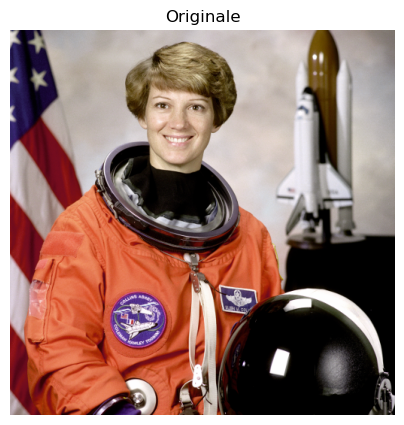

dtype: uint8
min/max: 0 255
shape: (512, 512, 3)


In [2]:
plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis('off')
plt.title('Originale')
plt.show()

print('dtype:', img.dtype)
print('min/max:', img.min(), img.max())
print('shape:', img.shape)

## 2) Normalizzazione 0-1 + grayscale (luminanza)

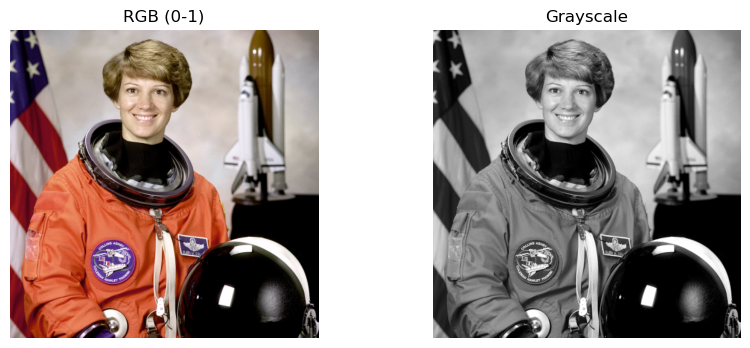

In [3]:
img_f = img.astype(np.float32)
img01 = img_f/255.0 if img_f.max()>1.5 else img_f

gray = 0.2126*img01[...,0] + 0.7152*img01[...,1] + 0.0722*img01[...,2]

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(img01)
plt.axis('off')
plt.title('RGB (0-1)')

plt.subplot(1,2,2)
plt.imshow(gray, cmap='gray')
plt.axis('off')
plt.title('Grayscale')
plt.show()

## 3) Operazioni pixel-wise (luminosità / negativo)

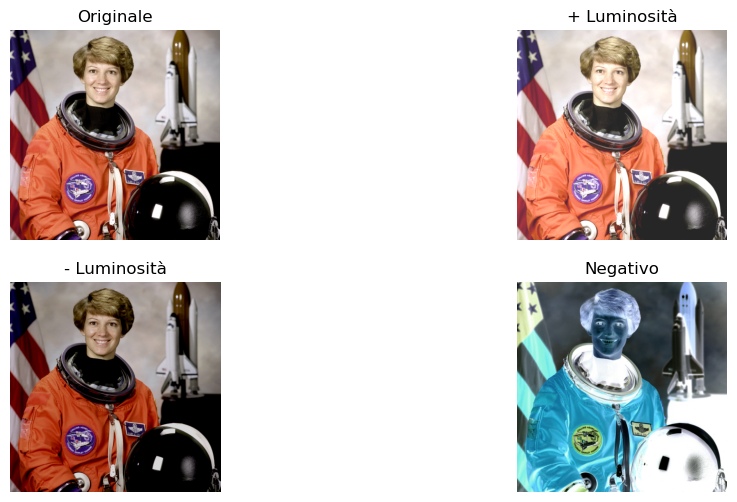

In [4]:
bright = np.clip(img01 + 0.15, 0, 1)
dark = np.clip(img01 - 0.15, 0, 1)
neg = 1 - img01

plt.figure(figsize=(12,6))
for i,(im,title) in enumerate([(img01,'Originale'),(bright,'+ Luminosità'),(dark,'- Luminosità'),(neg,'Negativo')]):
    plt.subplot(2,2,i+1)
    plt.imshow(im)
    plt.axis('off')
    plt.title(title)
plt.show()

## 4) Operazione globale: resize

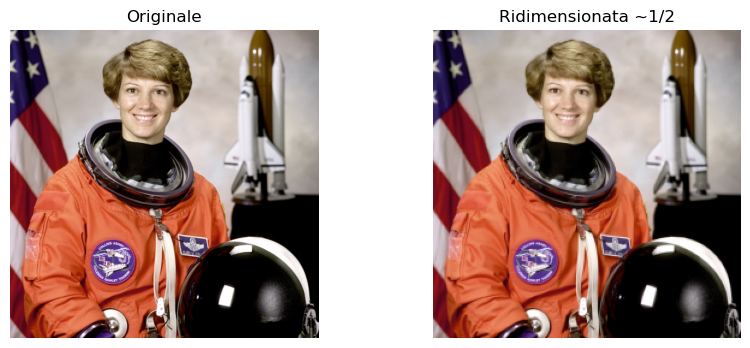

((512, 512, 3), (256, 256, 3))

In [5]:
try:
    from skimage.transform import resize
    small = resize(img01, (img01.shape[0]//2, img01.shape[1]//2), anti_aliasing=True)
except Exception as e:
    print('resize non disponibile, downsample semplice:', e)
    small = img01[::2, ::2]

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(img01); plt.axis('off'); plt.title('Originale')
plt.subplot(1,2,2); plt.imshow(small); plt.axis('off'); plt.title('Ridimensionata ~1/2')
plt.show()

img01.shape, small.shape

## 5) Operazioni locali: convoluzione (blur / edge)
Implementazione naive per capire bene cosa succede (non ottimizzata).

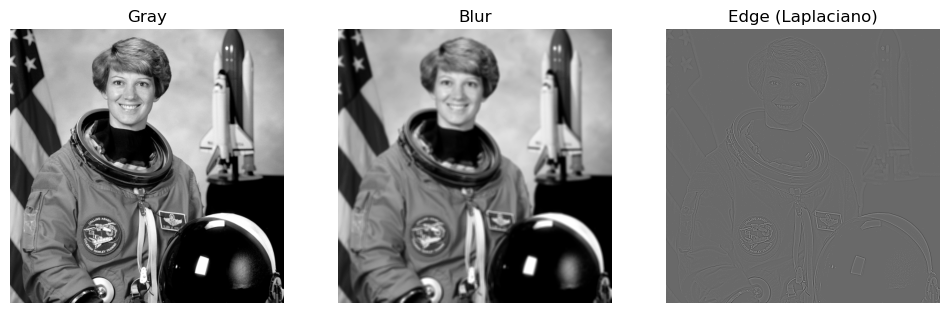

In [6]:
def conv2d(image, kernel, padding='reflect'):
    kh, kw = kernel.shape
    ph, pw = kh//2, kw//2
    mode = 'constant' if padding=='zero' else 'reflect'
    padded = np.pad(image, ((ph,ph),(pw,pw)), mode=mode)
    out = np.zeros_like(image, dtype=np.float32)
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            patch = padded[i:i+kh, j:j+kw]
            out[i,j] = np.sum(patch * kernel)
    return out

blur_k = np.ones((5,5), dtype=np.float32) / 25.0
edge_k = np.array([[0,-1,0],[-1,4,-1],[0,-1,0]], dtype=np.float32)

blurred = conv2d(gray, blur_k)
edges = conv2d(gray, edge_k)
edges_vis = (edges - edges.min()) / (edges.max() - edges.min() + 1e-9)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(gray, cmap='gray'); plt.axis('off'); plt.title('Gray')
plt.subplot(1,3,2); plt.imshow(blurred, cmap='gray'); plt.axis('off'); plt.title('Blur')
plt.subplot(1,3,3); plt.imshow(edges_vis, cmap='gray'); plt.axis('off'); plt.title('Edge (Laplaciano)')
plt.show()

### 5.1) Padding: reflect vs zero

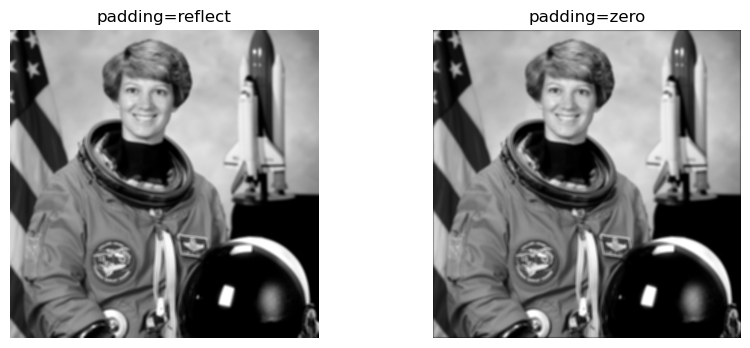

In [7]:
blur_reflect = conv2d(gray, blur_k, padding='reflect')
blur_zero = conv2d(gray, blur_k, padding='zero')

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(blur_reflect, cmap='gray'); plt.axis('off'); plt.title('padding=reflect')
plt.subplot(1,2,2); plt.imshow(blur_zero, cmap='gray'); plt.axis('off'); plt.title('padding=zero')
plt.show()

## 6) Collegamento alle CNN
Nelle CNN i kernel (filtri) vengono imparati: l’idea base resta un’operazione locale (convoluzione) che estrae pattern come bordi/texture.